In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn

     ---------------------------------------- 0.0/114.6 kB ? eta -:--:--
     ---------------------------------------- 0.0/114.6 kB ? eta -:--:--
     ---------------------------------------- 0.0/114.6 kB ? eta -:--:--
     ---------------------------------------- 0.0/114.6 kB ? eta -:--:--
     ---------------------------------------- 0.0/114.6 kB ? eta -:--:--
     ---------------------------------------- 0.0/114.6 kB ? eta -:--:--
     ---------------------------------------- 0.0/114.6 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/114.6 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/114.6 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/114.6 kB ? eta -:--:--
     ---------- ----------------------------- 30.7/114.6 kB ? eta -:--:--
     ------------- ----------------------- 41.0/114.6 kB 163.4 kB/s eta 0:00:01
     ------------- ----------------------- 41.0/114.6 kB 163.4 kB/s eta 0:00:01
     ------------- --------------


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA
from IPython.display import display
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv('./../datasets/Doctor/Merged_Doctor.csv')

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Dataset loaded: 2000 rows, 13 columns

First 5 rows:


,email,password,firstName,lastName,specialization,licenseNumber,experienceYears,phone,address,consultationFee,currency,imageUrl,createdAt
0,hboorer0@sciencedaily.com,$2a$04$wL1Nr/slwuXX9r/JGIj4QediX5BdpOdCW5d7MLS...,Hulda,Boorer,DERMATOLOGY,DOC-YSC-55982,10,5887245113,850 Carberry Alley,1288,CNY,http://dummyimage.com/157x100.png/5fa2dd/ffffff,2025-10-20 21:21:33
1,dgerish1@pen.io,$2a$04$zBnVCB/QFh5JMjVEI7iCXefoBWoWAqidwyK2e1x...,Dniren,Gerish,RADIOLOGY,DOC-VBS-85095,19,1198950700,5905 Ramsey Parkway,1784,ILS,http://dummyimage.com/146x100.png/5fa2dd/ffffff,2025-10-20 21:21:33
2,binglesfield2@opensource.org,$2a$04$90inHtJSnb6u5/aNfw3gpOxb95xQFtVaC/Cbl09...,Billy,Inglesfield,FAMILY_MEDICINE,DOC-KDM-03809,9,5171044165,57944 Merchant Circle,800,COP,http://dummyimage.com/204x100.png/cc0000/ffffff,2025-10-20 21:21:33
3,adrinkel3@over-blog.com,$2a$04$ukwod6Egyl9KA.PUp3CIsuS48Hry8NJtFOnwWYV...,Ailina,Drinkel,IMMUNOLOGY,DOC-ZXA-43626,20,1193669015,9 Independence Place,1941,LAK,http://dummyimage.com/203x100.png/ff4444/ffffff,2025-10-20 21:21:33
4,hpegram4@usgs.gov,$2a$04$gMQJYLwT1hkk.e9WV0eGe.fpSMRHpJicLBf3nkv...,Halley,Pegram,CARDIOLOGY,DOC-PIG-07938,19,8129677573,8429 Gale Terrace,1507,USD,http://dummyimage.com/172x100.png/dddddd/000000,2025-10-20 21:21:33


In [4]:
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   email            2000 non-null   object
 1   password         2000 non-null   object
 2   firstName        2000 non-null   object
 3   lastName         2000 non-null   object
 4   specialization   2000 non-null   object
 5   licenseNumber    2000 non-null   object
 6   experienceYears  2000 non-null   int64 
 7   phone            2000 non-null   int64 
 8   address          2000 non-null   object
 9   consultationFee  2000 non-null   int64 
 10  currency         2000 non-null   object
 11  imageUrl         2000 non-null   object
 12  createdAt        2000 non-null   object
dtypes: int64(3), object(10)
memory usage: 203.3+ KB
None

Missing Values:
email              0
password           0
firstName          0
lastName           0
specialization     0
licenseNumber      0
exp

,experienceYears,phone,consultationFee
count,2000.00000,2.000000e+03,2000.000000
mean,13.14700,5.541212e+09,1239.746000
std,7.15961,2.602381e+09,435.626939
min,1.00000,1.004939e+09,500.000000
25%,7.00000,3.282253e+09,846.000000
50%,13.00000,5.578323e+09,1250.000000
75%,19.25000,7.817063e+09,1618.000000
max,25.00000,9.996158e+09,2000.000000


In [5]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

print(f"\nUnique Specializations: {df['specialization'].nunique()}")
print(f"Unique Currencies: {df['currency'].nunique()}")
print(f"\nSpecialization Distribution:")
print(df['specialization'].value_counts())

Number of duplicate rows: 0

Unique Specializations: 29
Unique Currencies: 118

Specialization Distribution:
specialization
ENDOCRINOLOGY         96
FAMILY_MEDICINE       89
IMMUNOLOGY            83
GASTROENTEROLOGY      79
PLASTIC_SURGERY       79
PSYCHIATRY            77
SPORTS_MEDICINE       75
GENERAL_SURGERY       73
PATHOLOGY             72
DERMATOLOGY           71
RHEUMATOLOGY          70
RADIOLOGY             70
ANESTHESIOLOGY        69
CARDIOLOGY            68
PEDIATRICS            68
NEUROLOGY             67
UROLOGY               67
HEMATOLOGY            65
PULMONOLOGY           64
ONCOLOGY              63
INFECTIOUS_DISEASE    63
INTERNAL_MEDICINE     62
EMERGENCY_MEDICINE    62
DENTISTRY             62
GYNECOLOGY            61
ENT                   58
NEPHROLOGY            56
OPHTHALMOLOGY         56
ORTHOPEDICS           55
Name: count, dtype: int64


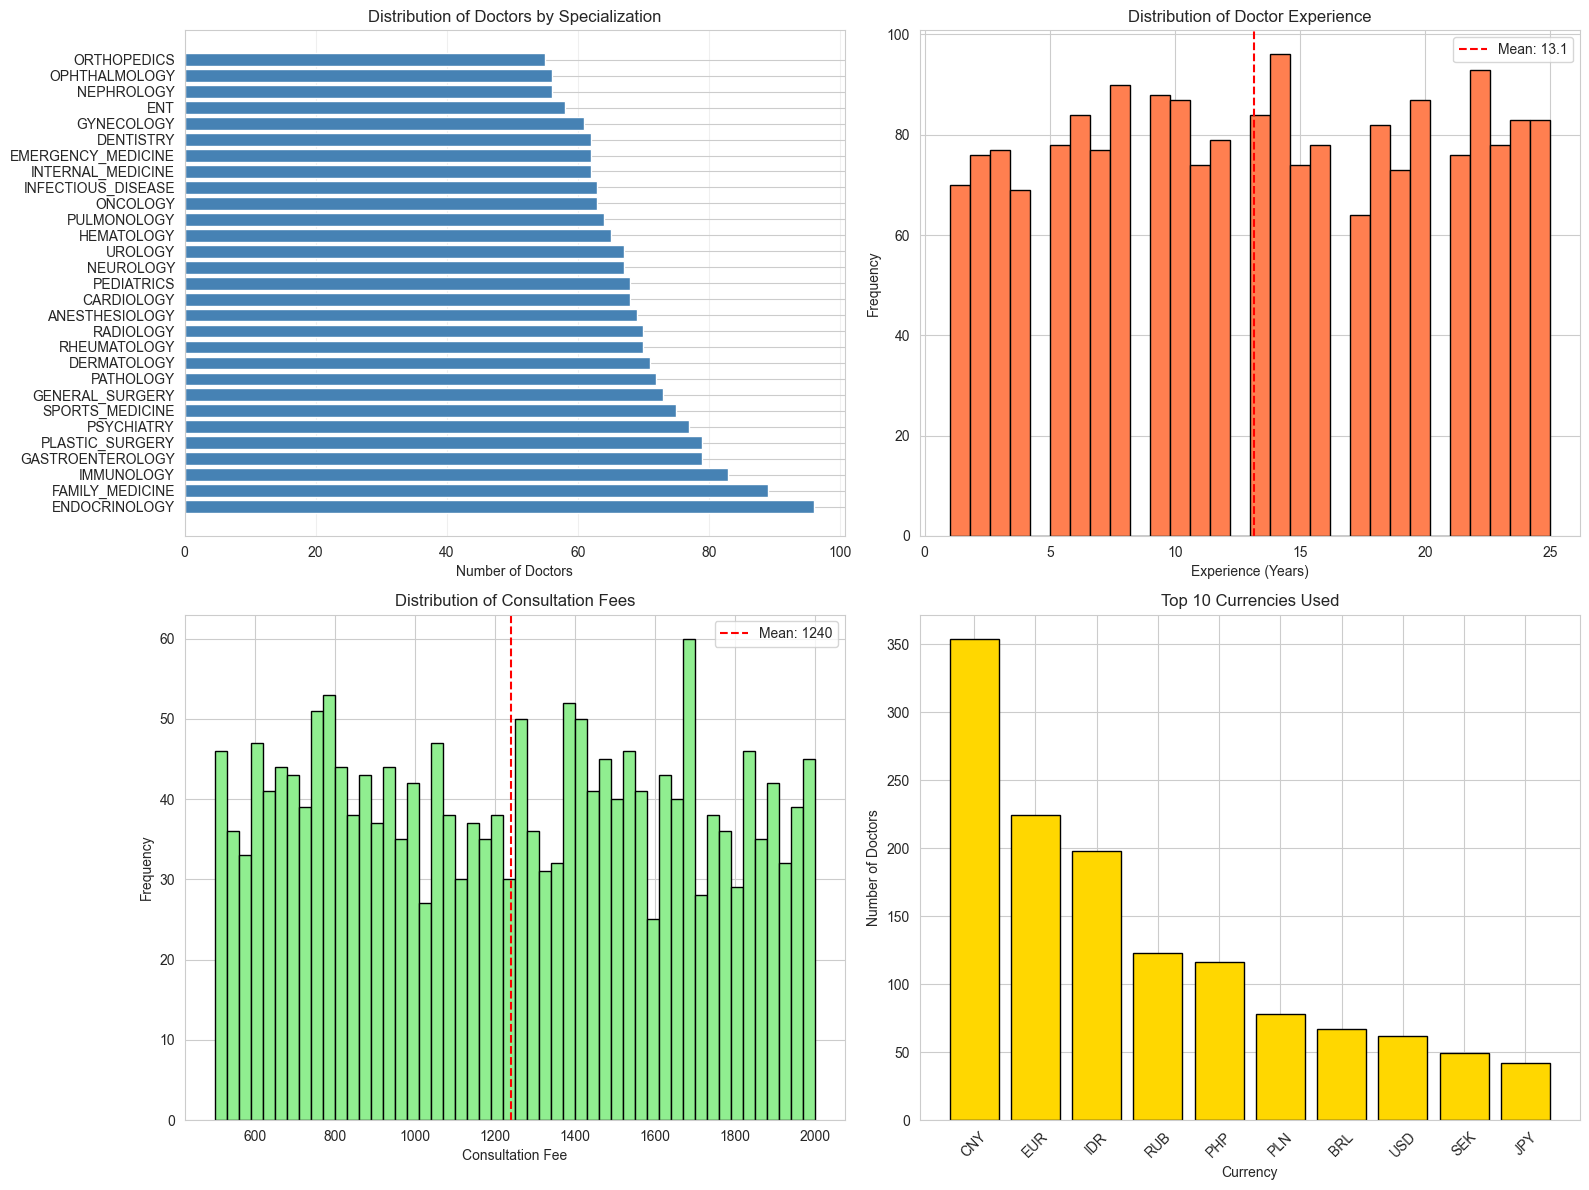

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

specialization_counts = df['specialization'].value_counts()
axes[0, 0].barh(specialization_counts.index, specialization_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Number of Doctors')
axes[0, 0].set_title('Distribution of Doctors by Specialization')
axes[0, 0].grid(axis='x', alpha=0.3)

axes[0, 1].hist(df['experienceYears'], bins=30, color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Experience (Years)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Doctor Experience')
axes[0, 1].axvline(df['experienceYears'].mean(), color='red', linestyle='--', label=f'Mean: {df["experienceYears"].mean():.1f}')
axes[0, 1].legend()

axes[1, 0].hist(df['consultationFee'], bins=50, color='lightgreen', edgecolor='black')
axes[1, 0].set_xlabel('Consultation Fee')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Consultation Fees')
axes[1, 0].axvline(df['consultationFee'].mean(), color='red', linestyle='--', label=f'Mean: {df["consultationFee"].mean():.0f}')
axes[1, 0].legend()

currency_counts = df['currency'].value_counts().head(10)
axes[1, 1].bar(currency_counts.index, currency_counts.values, color='gold', edgecolor='black')
axes[1, 1].set_xlabel('Currency')
axes[1, 1].set_ylabel('Number of Doctors')
axes[1, 1].set_title('Top 10 Currencies Used')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

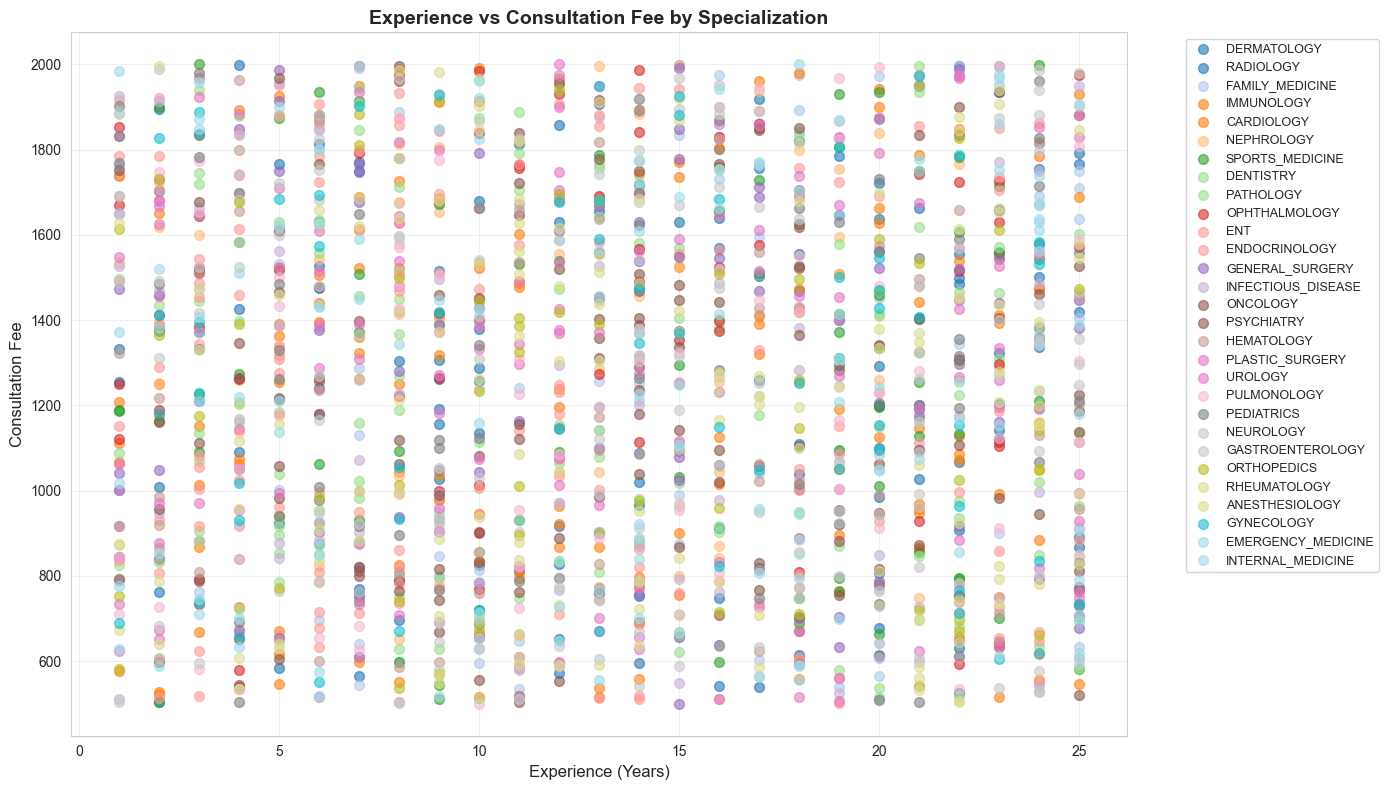

In [7]:
fig, ax = plt.subplots(figsize=(14, 8))

specializations = df['specialization'].unique()
colors = plt.cm.tab20(np.linspace(0, 1, len(specializations)))

for spec, color in zip(specializations, colors):
    spec_data = df[df['specialization'] == spec]
    ax.scatter(spec_data['experienceYears'], spec_data['consultationFee'], 
               label=spec, alpha=0.6, s=50, color=color)

ax.set_xlabel('Experience (Years)', fontsize=12)
ax.set_ylabel('Consultation Fee', fontsize=12)
ax.set_title('Experience vs Consultation Fee by Specialization', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

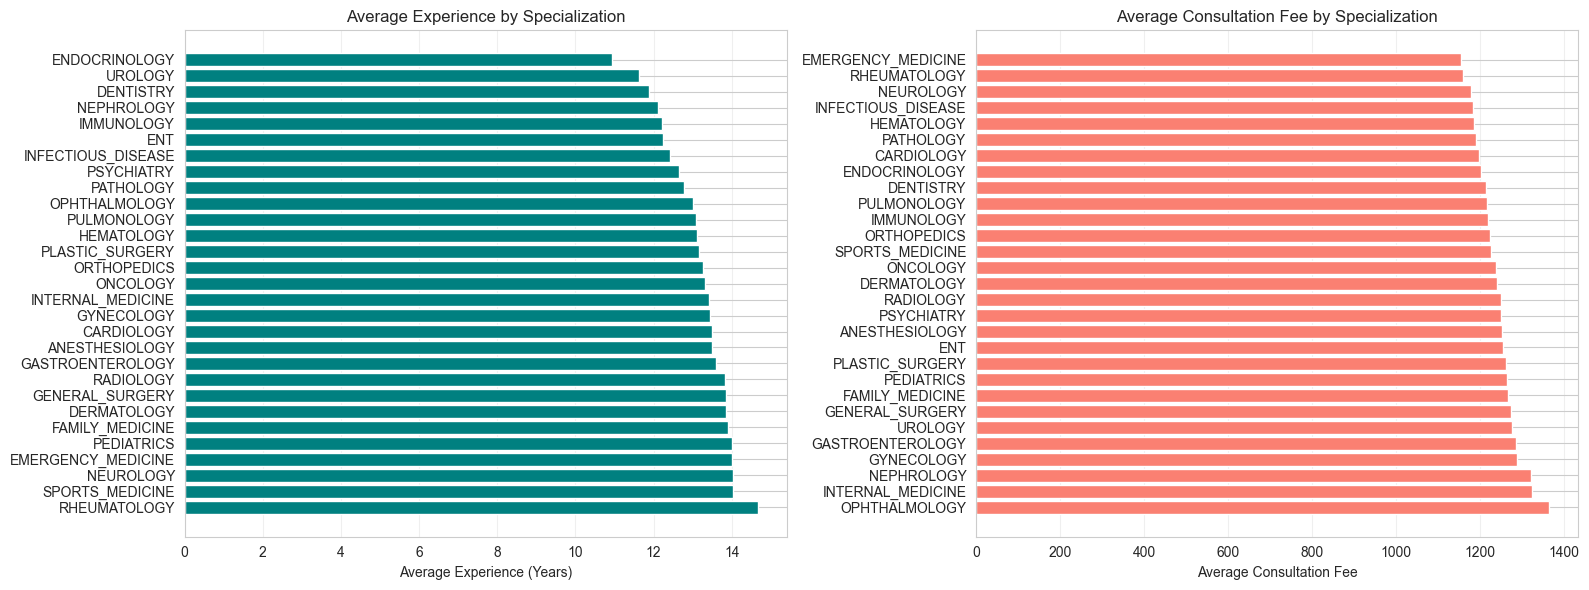

In [8]:
spec_stats = df.groupby('specialization').agg({
    'experienceYears': 'mean',
    'consultationFee': 'mean',
    'email': 'count'
}).rename(columns={'email': 'count'}).sort_values('experienceYears', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(spec_stats.index, spec_stats['experienceYears'], color='teal')
axes[0].set_xlabel('Average Experience (Years)')
axes[0].set_title('Average Experience by Specialization')
axes[0].grid(axis='x', alpha=0.3)

spec_stats_fee = spec_stats.sort_values('consultationFee', ascending=False)
axes[1].barh(spec_stats_fee.index, spec_stats_fee['consultationFee'], color='salmon')
axes[1].set_xlabel('Average Consultation Fee')
axes[1].set_title('Average Consultation Fee by Specialization')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

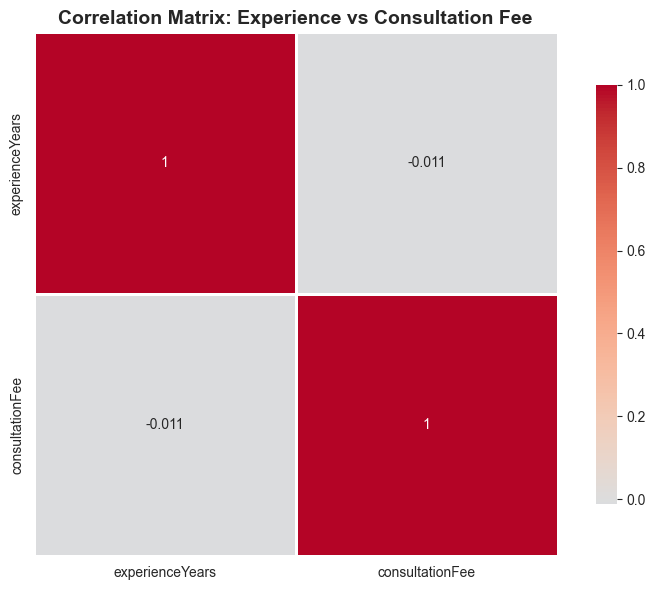

Correlation between Experience and Consultation Fee: -0.011


In [9]:
numeric_cols = ['experienceYears', 'consultationFee']
correlation = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix: Experience vs Consultation Fee', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Correlation between Experience and Consultation Fee: {correlation.iloc[0, 1]:.3f}")

In [10]:
df_model = df.copy()

df_model['normalized_fee'] = df_model.groupby('currency')['consultationFee'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0
)

exp_scaler = MinMaxScaler()
df_model['normalized_experience'] = exp_scaler.fit_transform(df_model[['experienceYears']])

print("Feature Engineering Complete!")
print(f"\nNormalized Fee Range: [{df_model['normalized_fee'].min():.3f}, {df_model['normalized_fee'].max():.3f}]")
print(f"Normalized Experience Range: [{df_model['normalized_experience'].min():.3f}, {df_model['normalized_experience'].max():.3f}]")

Feature Engineering Complete!

Normalized Fee Range: [0.000, 1.000]
Normalized Experience Range: [0.000, 1.000]


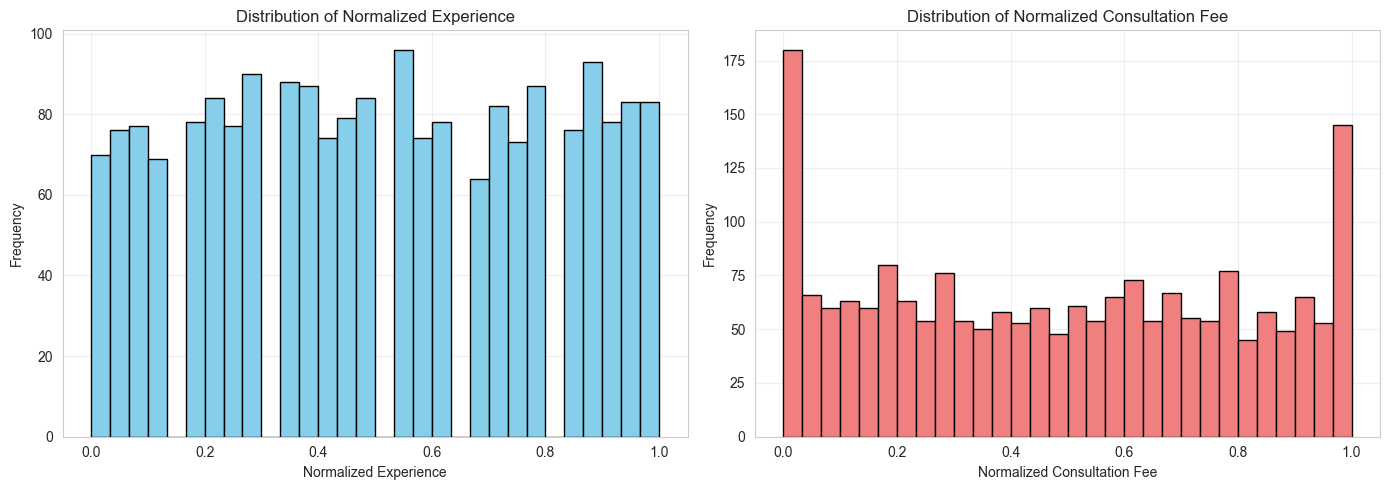

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_model['normalized_experience'], bins=30, color='skyblue', edgecolor='black')
axes[0].set_xlabel('Normalized Experience')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Normalized Experience')
axes[0].grid(alpha=0.3)

axes[1].hist(df_model['normalized_fee'], bins=30, color='lightcoral', edgecolor='black')
axes[1].set_xlabel('Normalized Consultation Fee')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Normalized Consultation Fee')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
class DoctorRecommendationModel:
    """
    Advanced Doctor Recommendation Model
    
    This model ranks doctors based on:
    1. Specialization match (required)
    2. Experience (higher is better)
    3. Consultation fee (lower is better)
    
    The model uses configurable weights for experience and fee.
    """
    
    def __init__(self, df, experience_weight=0.5, fee_weight=0.5):
        """
        Initialize the recommendation model
        
        Parameters:
        - df: DataFrame with doctor data
        - experience_weight: Weight for experience (default: 0.5)
        - fee_weight: Weight for consultation fee (default: 0.5)
        """
        self.df = df.copy()
        self.experience_weight = experience_weight
        self.fee_weight = fee_weight
        
        if 'normalized_experience' not in self.df.columns:
            self._normalize_features()
        
        self._calculate_scores()
    
    def _normalize_features(self):
        """Normalize experience and consultation fees"""
        self.df['normalized_fee'] = self.df.groupby('currency')['consultationFee'].transform(
            lambda x: (x - x.min()) / (x.max() - x.min()) if x.max() != x.min() else 0
        )
        
        exp_scaler = MinMaxScaler()
        self.df['normalized_experience'] = exp_scaler.fit_transform(self.df[['experienceYears']])
    
    def _calculate_scores(self):
        """Calculate the composite recommendation score"""
        self.df['fee_score'] = 1 - self.df['normalized_fee']
        
        self.df['experience_score'] = self.df['normalized_experience']
        
        self.df['recommendation_score'] = (
            self.experience_weight * self.df['experience_score'] +
            self.fee_weight * self.df['fee_score']
        )
    
    def recommend(self, specialization, top_n=10, min_experience=0, max_fee=None, currency=None):
        """
        Get top N doctor recommendations for a specific specialization
        
        Parameters:
        - specialization: Required medical specialization
        - top_n: Number of top recommendations to return (default: 10)
        - min_experience: Minimum years of experience (default: 0)
        - max_fee: Maximum consultation fee (default: None)
        - currency: Filter by specific currency (default: None)
        
        Returns:
        - DataFrame with top N recommended doctors
        """
        filtered_df = self.df[self.df['specialization'] == specialization].copy()
        
        if filtered_df.empty:
            print(f"No doctors found for specialization: {specialization}")
            return pd.DataFrame()
        
        if min_experience > 0:
            filtered_df = filtered_df[filtered_df['experienceYears'] >= min_experience]
        
        if max_fee is not None:
            filtered_df = filtered_df[filtered_df['consultationFee'] <= max_fee]
        
        if currency is not None:
            filtered_df = filtered_df[filtered_df['currency'] == currency]
        
        if filtered_df.empty:
            print("No doctors match the specified criteria")
            return pd.DataFrame()
        
        recommendations = filtered_df.sort_values('recommendation_score', ascending=False).head(top_n)
        
        output_cols = [
            'firstName', 'lastName', 'specialization', 'experienceYears',
            'consultationFee', 'currency', 'phone', 'email',
            'recommendation_score', 'experience_score', 'fee_score'
        ]
        
        return recommendations[output_cols].reset_index(drop=True)
    
    def get_best_doctor(self, specialization, min_experience=0, max_fee=None, currency=None):
        """
        Get the single best doctor for a specialization
        
        Parameters: Same as recommend()
        
        Returns:
        - Series with the best doctor's information
        """
        recommendations = self.recommend(specialization, top_n=1, 
                                        min_experience=min_experience,
                                        max_fee=max_fee, currency=currency)
        
        if recommendations.empty:
            return None
        
        return recommendations.iloc[0]
    
    def compare_doctors(self, doctor_ids):
        """
        Compare multiple doctors by their indices
        
        Parameters:
        - doctor_ids: List of doctor indices to compare
        
        Returns:
        - DataFrame with comparison details
        """
        comparison = self.df.iloc[doctor_ids].copy()
        
        output_cols = [
            'firstName', 'lastName', 'specialization', 'experienceYears',
            'consultationFee', 'currency', 'recommendation_score',
            'experience_score', 'fee_score'
        ]
        
        return comparison[output_cols]
    
    def get_statistics(self, specialization=None):
        """
        Get statistics for all doctors or a specific specialization
        
        Parameters:
        - specialization: Optional specialization filter
        
        Returns:
        - Dictionary with statistics
        """
        if specialization:
            data = self.df[self.df['specialization'] == specialization]
        else:
            data = self.df
        
        stats = {
            'total_doctors': len(data),
            'avg_experience': data['experienceYears'].mean(),
            'max_experience': data['experienceYears'].max(),
            'min_experience': data['experienceYears'].min(),
            'avg_fee': data['consultationFee'].mean(),
            'max_fee': data['consultationFee'].max(),
            'min_fee': data['consultationFee'].min(),
            'avg_recommendation_score': data['recommendation_score'].mean()
        }
        
        return stats

print("Doctor Recommendation Model class created successfully!")

Doctor Recommendation Model class created successfully!


In [13]:
model = DoctorRecommendationModel(df_model, experience_weight=0.5, fee_weight=0.5)

print("Model initialized successfully!")
print(f"\nTotal doctors in database: {len(model.df)}")
print(f"Available specializations: {model.df['specialization'].nunique()}")

Model initialized successfully!

Total doctors in database: 2000
Available specializations: 29


In [14]:
test_specialization = 'CARDIOLOGY'

print(f"\n{'='*80}")
print(f"TOP 10 RECOMMENDED DOCTORS FOR {test_specialization}")
print(f"{'='*80}\n")

recommendations = model.recommend(test_specialization, top_n=10)

if not recommendations.empty:
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', None)
    pd.set_option('display.float_format', '{:.3f}'.format)
    
    display(recommendations)
    
    stats = model.get_statistics(test_specialization)
    print(f"\n{'='*80}")
    print(f"STATISTICS FOR {test_specialization}")
    print(f"{'='*80}")
    for key, value in stats.items():
        print(f"{key.replace('_', ' ').title()}: {value:.2f}")
else:
    print(f"No doctors found for {test_specialization}")


TOP 10 RECOMMENDED DOCTORS FOR CARDIOLOGY



,firstName,lastName,specialization,experienceYears,consultationFee,currency,phone,email,recommendation_score,experience_score,fee_score
0,Brucie,Stango,CARDIOLOGY,25,546,IDR,6666873495,bstangoof@vinaora.com,0.988,1.000,0.976
1,Adina,Thurlbeck,CARDIOLOGY,24,556,SEK,8987682815,athurlbeckl6@google.ru,0.979,0.958,1.000
2,Cordie,Burdoun,CARDIOLOGY,23,993,KZT,9299848741,cburdoun9d@yellowbook.com,0.958,0.917,1.000
3,Egan,Caplis,CARDIOLOGY,23,515,CNY,4796887046,ecaplisas@usgs.gov,0.953,0.917,0.990
4,Conrad,Palluschek,CARDIOLOGY,21,864,TZS,9324569751,cpalluschekby@harvard.edu,0.911,0.833,0.990
5,Isacco,Dunkerton,CARDIOLOGY,23,750,EUR,8761744373,idunkerton1n@people.com.cn,0.876,0.917,0.835
6,Vic,Prigg,CARDIOLOGY,18,603,EUR,7226429888,vprigghp@mit.edu,0.821,0.708,0.933
7,Iggy,Abrahamowitcz,CARDIOLOGY,15,1771,BZD,5484153376,iabrahamowitcz2t@google.ru,0.792,0.583,1.000
8,Emma,Weiner,CARDIOLOGY,19,762,IDR,4802600619,eweinerdt@51.la,0.790,0.750,0.830
9,Palmer,Flaonier,CARDIOLOGY,21,958,IDR,3206770387,pflaonieriv@psu.edu,0.766,0.833,0.699



STATISTICS FOR CARDIOLOGY
Total Doctors: 68.00
Avg Experience: 13.49
Max Experience: 25.00
Min Experience: 1.00
Avg Fee: 1199.37
Max Fee: 1991.00
Min Fee: 515.00
Avg Recommendation Score: 0.54


In [15]:
specializations = model.df['specialization'].unique()

print(f"\n{'='*80}")
print("BEST DOCTOR FOR EACH SPECIALIZATION")
print(f"{'='*80}\n")

best_doctors = []

for spec in sorted(specializations):
    best = model.get_best_doctor(spec)
    if best is not None:
        best_doctors.append({
            'Specialization': spec,
            'Doctor': f"{best['firstName']} {best['lastName']}",
            'Experience': best['experienceYears'],
            'Fee': f"{best['consultationFee']} {best['currency']}",
            'Score': f"{best['recommendation_score']:.3f}",
            'Email': best['email']
        })

best_doctors_df = pd.DataFrame(best_doctors)
display(best_doctors_df)


BEST DOCTOR FOR EACH SPECIALIZATION



,Specialization,Doctor,Experience,Fee,Score,Email
0,ANESTHESIOLOGY,Ramon Josofovitz,21,532 XAF,0.911,rjosofovitzj3@sakura.ne.jp
1,CARDIOLOGY,Brucie Stango,25,546 IDR,0.988,bstangoof@vinaora.com
2,DENTISTRY,Viviana Jamary,25,584 CNY,0.972,vjamary7@goo.gl
3,DERMATOLOGY,Rodney Dasent,22,1066 SYP,0.931,rdasentgw@economist.com
4,EMERGENCY_MEDICINE,Andeee Hanscome,25,607 PLN,0.966,ahanscomebe@stanford.edu
5,ENDOCRINOLOGY,Travers Osler,25,608 NGN,0.985,toslerif@abc.net.au
6,ENT,Corey Sabathe,24,668 TJS,0.979,csabathejo@hugedomains.com
7,FAMILY_MEDICINE,Nikita Buckbee,25,632 EUR,0.957,nbuckbeeh8@netscape.com
8,GASTROENTEROLOGY,Kelley Jaffray,19,1068 HUF,0.875,kjaffraya2@nih.gov
9,GENERAL_SURGERY,Filip Yearby,25,677 XAF,0.945,fyearbyrc@comsenz.com


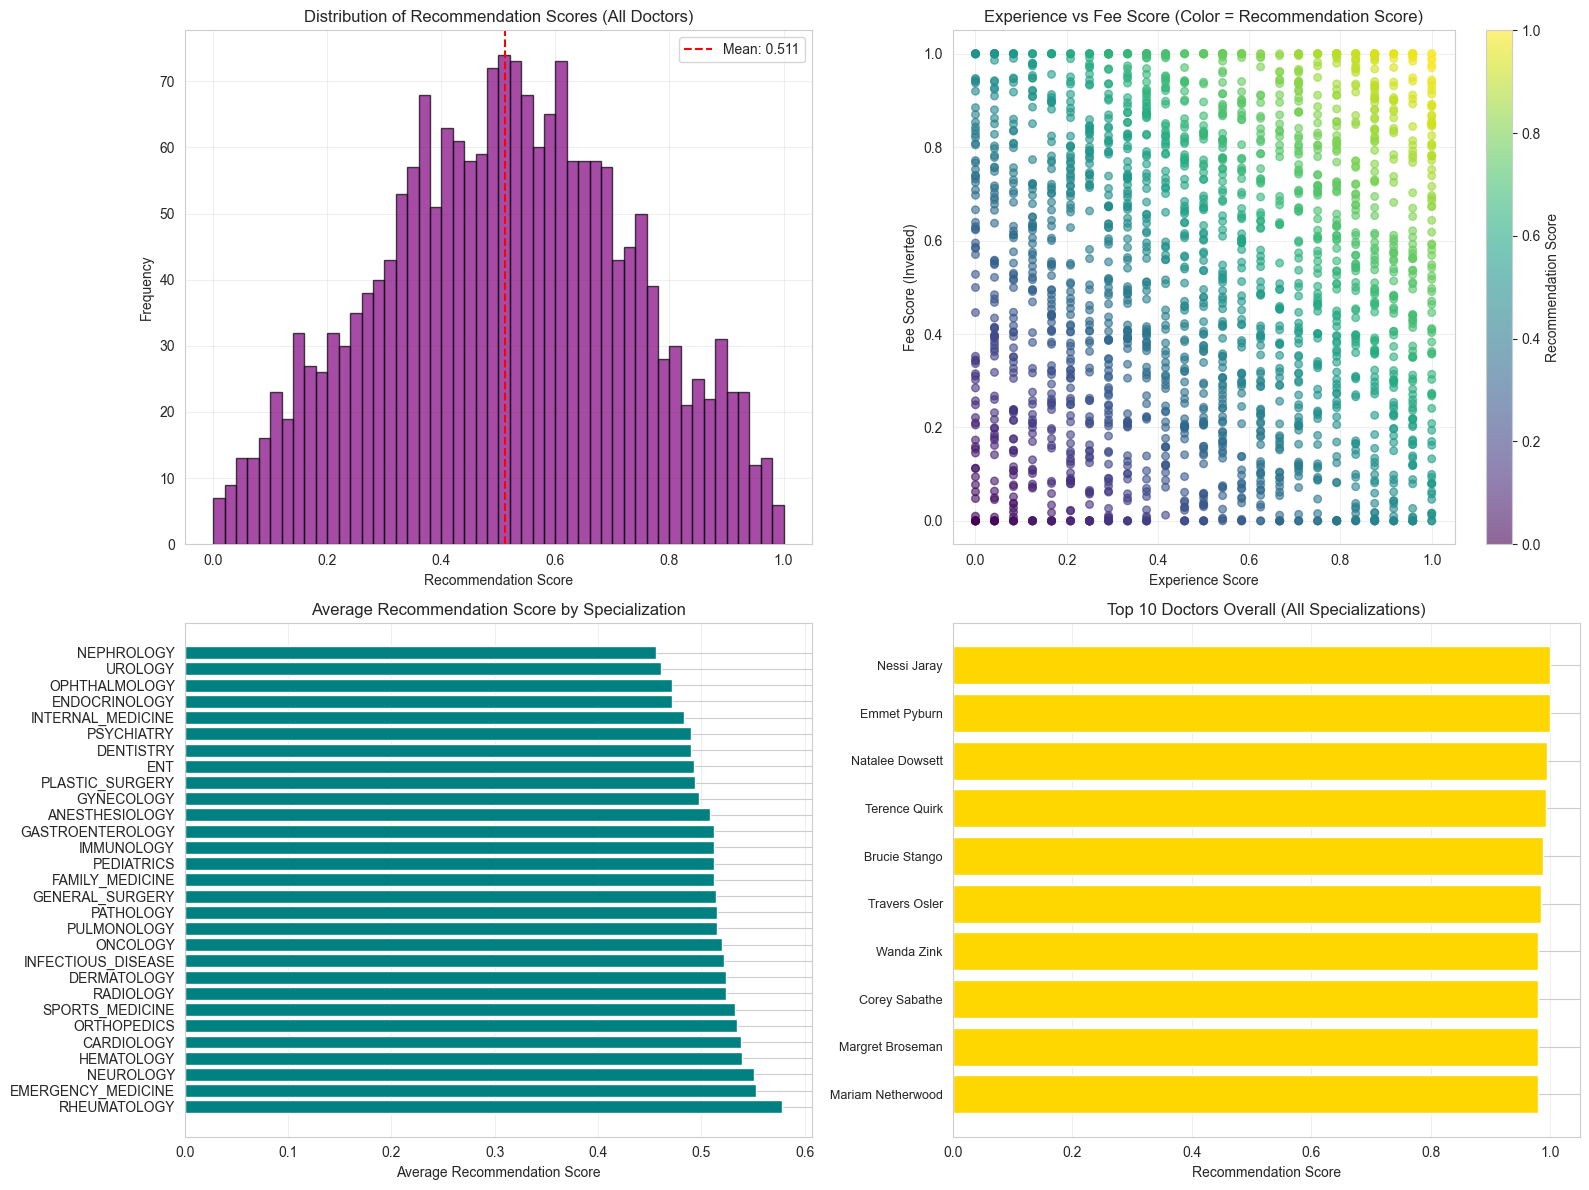

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

axes[0, 0].hist(model.df['recommendation_score'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Recommendation Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Recommendation Scores (All Doctors)')
axes[0, 0].axvline(model.df['recommendation_score'].mean(), color='red', linestyle='--', 
                   label=f'Mean: {model.df["recommendation_score"].mean():.3f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

scatter = axes[0, 1].scatter(model.df['experience_score'], model.df['fee_score'], 
                             c=model.df['recommendation_score'], cmap='viridis', 
                             alpha=0.6, s=30)
axes[0, 1].set_xlabel('Experience Score')
axes[0, 1].set_ylabel('Fee Score (Inverted)')
axes[0, 1].set_title('Experience vs Fee Score (Color = Recommendation Score)')
axes[0, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[0, 1], label='Recommendation Score')

avg_scores = model.df.groupby('specialization')['recommendation_score'].mean().sort_values(ascending=False)
axes[1, 0].barh(avg_scores.index, avg_scores.values, color='teal')
axes[1, 0].set_xlabel('Average Recommendation Score')
axes[1, 0].set_title('Average Recommendation Score by Specialization')
axes[1, 0].grid(axis='x', alpha=0.3)

top_10_overall = model.df.nlargest(10, 'recommendation_score')
doctor_names = top_10_overall['firstName'] + ' ' + top_10_overall['lastName']
axes[1, 1].barh(range(10), top_10_overall['recommendation_score'].values, color='gold')
axes[1, 1].set_yticks(range(10))
axes[1, 1].set_yticklabels(doctor_names.values, fontsize=9)
axes[1, 1].set_xlabel('Recommendation Score')
axes[1, 1].set_title('Top 10 Doctors Overall (All Specializations)')
axes[1, 1].grid(axis='x', alpha=0.3)
axes[1, 1].invert_yaxis()

plt.tight_layout()
plt.show()

In [17]:
print("\n" + "="*80)
print("CUSTOM SEARCH: Cardiologists with 15+ years experience")
print("="*80 + "\n")

custom_search = model.recommend('CARDIOLOGY', top_n=5, min_experience=15)
display(custom_search)


CUSTOM SEARCH: Cardiologists with 15+ years experience



,firstName,lastName,specialization,experienceYears,consultationFee,currency,phone,email,recommendation_score,experience_score,fee_score
0,Brucie,Stango,CARDIOLOGY,25,546,IDR,6666873495,bstangoof@vinaora.com,0.988,1.000,0.976
1,Adina,Thurlbeck,CARDIOLOGY,24,556,SEK,8987682815,athurlbeckl6@google.ru,0.979,0.958,1.000
2,Cordie,Burdoun,CARDIOLOGY,23,993,KZT,9299848741,cburdoun9d@yellowbook.com,0.958,0.917,1.000
3,Egan,Caplis,CARDIOLOGY,23,515,CNY,4796887046,ecaplisas@usgs.gov,0.953,0.917,0.990
4,Conrad,Palluschek,CARDIOLOGY,21,864,TZS,9324569751,cpalluschekby@harvard.edu,0.911,0.833,0.990


In [18]:
print("\n" + "="*80)
print("CUSTOM SEARCH: Dermatologists with fees under 1000")
print("="*80 + "\n")

affordable_search = model.recommend('DERMATOLOGY', top_n=5, max_fee=1000)
display(affordable_search)


CUSTOM SEARCH: Dermatologists with fees under 1000



,firstName,lastName,specialization,experienceYears,consultationFee,currency,phone,email,recommendation_score,experience_score,fee_score
0,Boris,Lowson,DERMATOLOGY,25,868,COP,5757131953,blowsonib@mashable.com,0.902,1.000,0.805
1,Athene,Thebeaud,DERMATOLOGY,22,631,CNY,3218229212,athebeaud0@arstechnica.com,0.894,0.875,0.913
2,Salim,Moizer,DERMATOLOGY,25,891,AMD,9528845929,smoizerj8@springer.com,0.846,1.000,0.691
3,Reinhard,Simonds,DERMATOLOGY,20,677,CNY,5354370933,rsimondsg5@google.com.au,0.837,0.792,0.882
4,Marleen,Peterson,DERMATOLOGY,18,614,SEK,8717078301,mpetersoncb@scientificamerican.com,0.834,0.708,0.960


In [19]:
def test_weight_sensitivity(specialization='CARDIOLOGY', top_n=5):
    """
    Test how different weight combinations affect recommendations
    """
    weight_combinations = [
        (0.7, 0.3, 'Experience-focused'),
        (0.5, 0.5, 'Balanced'),
        (0.3, 0.7, 'Price-focused')
    ]
    
    results = {}
    
    for exp_weight, fee_weight, label in weight_combinations:
        temp_model = DoctorRecommendationModel(df_model, 
                                               experience_weight=exp_weight, 
                                               fee_weight=fee_weight)
        recommendations = temp_model.recommend(specialization, top_n=top_n)
        results[label] = recommendations[['firstName', 'lastName', 'experienceYears', 
                                          'consultationFee', 'recommendation_score']]
    
    return results

print("\n" + "="*80)
print("WEIGHT SENSITIVITY ANALYSIS")
print("="*80 + "\n")

sensitivity_results = test_weight_sensitivity('CARDIOLOGY', top_n=3)

for label, result in sensitivity_results.items():
    print(f"\n{label} Model (Top 3):")
    print("-" * 80)
    display(result)


WEIGHT SENSITIVITY ANALYSIS


Experience-focused Model (Top 3):
--------------------------------------------------------------------------------


,firstName,lastName,experienceYears,consultationFee,recommendation_score
0,Brucie,Stango,25,546,0.993
1,Adina,Thurlbeck,24,556,0.971
2,Cordie,Burdoun,23,993,0.942



Balanced Model (Top 3):
--------------------------------------------------------------------------------


,firstName,lastName,experienceYears,consultationFee,recommendation_score
0,Brucie,Stango,25,546,0.988
1,Adina,Thurlbeck,24,556,0.979
2,Cordie,Burdoun,23,993,0.958



Price-focused Model (Top 3):
--------------------------------------------------------------------------------


,firstName,lastName,experienceYears,consultationFee,recommendation_score
0,Adina,Thurlbeck,24,556,0.987
1,Brucie,Stango,25,546,0.983
2,Cordie,Burdoun,23,993,0.975


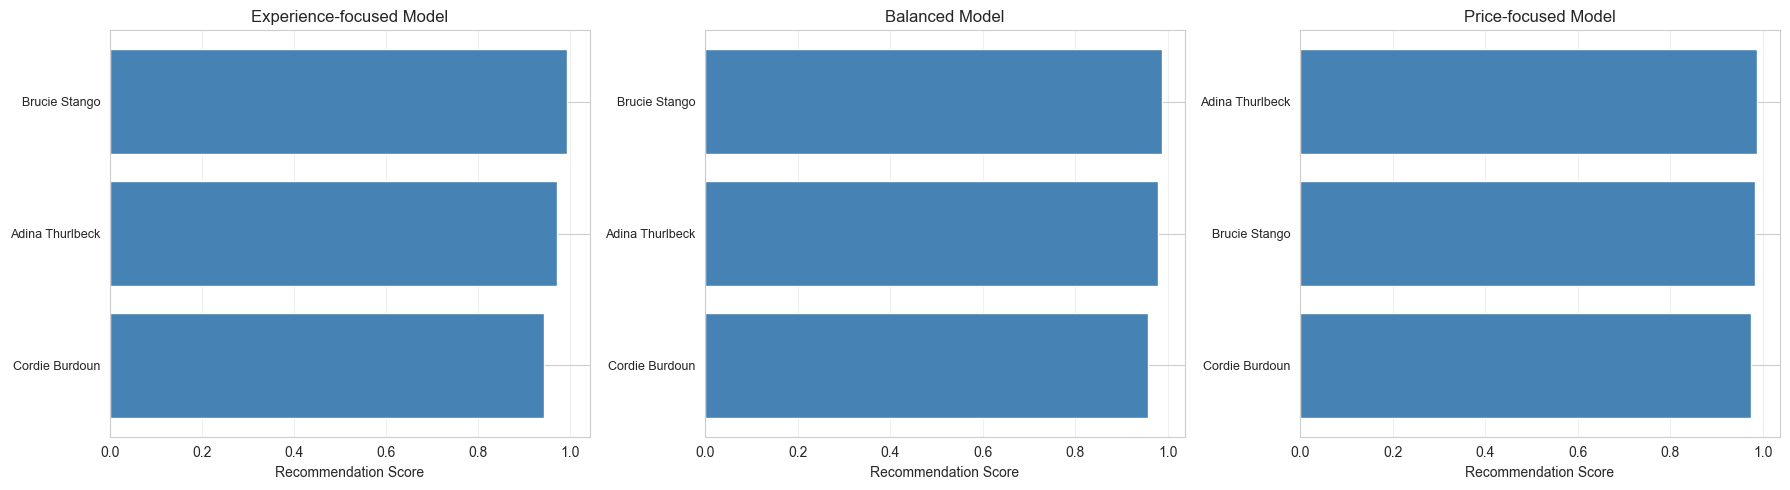

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (label, result) in enumerate(sensitivity_results.items()):
    doctor_names = result['firstName'] + ' ' + result['lastName']
    axes[idx].barh(range(len(result)), result['recommendation_score'].values, color='steelblue')
    axes[idx].set_yticks(range(len(result)))
    axes[idx].set_yticklabels(doctor_names.values, fontsize=9)
    axes[idx].set_xlabel('Recommendation Score')
    axes[idx].set_title(f'{label} Model')
    axes[idx].grid(axis='x', alpha=0.3)
    axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

In [21]:
import os
import pickle

output_df = model.df[[
    'email', 'firstName', 'lastName', 'specialization', 'licenseNumber',
    'experienceYears', 'phone', 'address', 'consultationFee', 'currency',
    'recommendation_score', 'experience_score', 'fee_score'
]].sort_values('recommendation_score', ascending=False)

output_dir = './../models/Doctor'
os.makedirs(output_dir, exist_ok=True)

output_pickle_path = os.path.join(output_dir, 'doctors_with_scores.pkl')
best_doctors_pickle_path = os.path.join(output_dir, 'best_doctors_by_specialization.pkl')

with open(output_pickle_path, 'wb') as f:
    pickle.dump(output_df, f)
print(f"✓ Complete scored dataset saved to '{output_pickle_path}'")

with open(best_doctors_pickle_path, 'wb') as f:
    pickle.dump(best_doctors_df, f)
print(f"✓ Best doctors by specialization saved to '{best_doctors_pickle_path}'")


✓ Complete scored dataset saved to './../models/Doctor\doctors_with_scores.pkl'
✓ Best doctors by specialization saved to './../models/Doctor\best_doctors_by_specialization.pkl'


In [22]:
def find_doctor(specialization, top_n=5, min_experience=0, max_fee=None, currency=None, show_details=True):
    """
    User-friendly function to find doctors
    
    Usage Examples:
    - find_doctor('CARDIOLOGY')
    - find_doctor('DERMATOLOGY', top_n=3, min_experience=10)
    - find_doctor('PEDIATRICS', max_fee=1000, currency='USD')
    """
    print(f"\n{'='*80}")
    print(f"SEARCHING FOR: {specialization}")
    
    if min_experience > 0:
        print(f"Minimum Experience: {min_experience} years")
    if max_fee:
        print(f"Maximum Fee: {max_fee}")
    if currency:
        print(f"Currency: {currency}")
    
    print(f"{'='*80}\n")
    
    results = model.recommend(specialization, top_n=top_n, 
                             min_experience=min_experience,
                             max_fee=max_fee, currency=currency)
    
    if results.empty:
        print("No doctors found matching your criteria.")
        return None
    
    if show_details:
        print(f"Found {len(results)} doctor(s):\n")
        for idx, row in results.iterrows():
            print(f"\n{idx + 1}. Dr. {row['firstName']} {row['lastName']}")
            print(f"   Experience: {row['experienceYears']} years")
            print(f"   Consultation Fee: {row['consultationFee']} {row['currency']}")
            print(f"   Recommendation Score: {row['recommendation_score']:.3f}")
            print(f"   Contact: {row['email']} | {row['phone']}")
    
    return results

print("\nExample: Finding the top 3 cardiologists")
results = find_doctor('CARDIOLOGY', top_n=3)


Example: Finding the top 3 cardiologists

SEARCHING FOR: CARDIOLOGY

Found 3 doctor(s):


1. Dr. Brucie Stango
   Experience: 25 years
   Consultation Fee: 546 IDR
   Recommendation Score: 0.988
   Contact: bstangoof@vinaora.com | 6666873495

2. Dr. Adina Thurlbeck
   Experience: 24 years
   Consultation Fee: 556 SEK
   Recommendation Score: 0.979
   Contact: athurlbeckl6@google.ru | 8987682815

3. Dr. Cordie Burdoun
   Experience: 23 years
   Consultation Fee: 993 KZT
   Recommendation Score: 0.958
   Contact: cburdoun9d@yellowbook.com | 9299848741


In [23]:
print("\n" + "="*80)
print("MODEL SUMMARY AND KEY INSIGHTS")
print("="*80 + "\n")

print("1. MODEL ARCHITECTURE:")
print("   - Normalized experience and consultation fees for fair comparison")
print("   - Weighted scoring system (configurable weights)")
print("   - Handles multiple currencies through within-group normalization")
print("   - Filters available: specialization, experience, fee, currency\n")

print("2. SCORING FORMULA:")
print("   Recommendation Score = (w1 × Experience Score) + (w2 × Inverted Fee Score)")
print(f"   Current weights: w1={model.experience_weight}, w2={model.fee_weight}\n")

print("3. KEY STATISTICS:")
overall_stats = model.get_statistics()
for key, value in overall_stats.items():
    print(f"   {key.replace('_', ' ').title()}: {value:.2f}")

print("\n4. TOP PERFORMING SPECIALIZATIONS (by avg score):")
top_specs = model.df.groupby('specialization')['recommendation_score'].mean().sort_values(ascending=False).head(5)
for spec, score in top_specs.items():
    print(f"   {spec}: {score:.3f}")

print("\n5. MODEL STRENGTHS:")
print("   ✓ Fair comparison across currencies")
print("   ✓ Balances experience and cost considerations")
print("   ✓ Flexible filtering options")
print("   ✓ Configurable weights for different priorities")
print("   ✓ Fast recommendations for any specialization")

print("\n" + "="*80)


MODEL SUMMARY AND KEY INSIGHTS

1. MODEL ARCHITECTURE:
   - Normalized experience and consultation fees for fair comparison
   - Weighted scoring system (configurable weights)
   - Handles multiple currencies through within-group normalization
   - Filters available: specialization, experience, fee, currency

2. SCORING FORMULA:
   Recommendation Score = (w1 × Experience Score) + (w2 × Inverted Fee Score)
   Current weights: w1=0.5, w2=0.5

3. KEY STATISTICS:
   Total Doctors: 2000.00
   Avg Experience: 13.15
   Max Experience: 25.00
   Min Experience: 1.00
   Avg Fee: 1239.75
   Max Fee: 2000.00
   Min Fee: 500.00
   Avg Recommendation Score: 0.51

4. TOP PERFORMING SPECIALIZATIONS (by avg score):
   RHEUMATOLOGY: 0.578
   EMERGENCY_MEDICINE: 0.553
   NEUROLOGY: 0.551
   HEMATOLOGY: 0.539
   CARDIOLOGY: 0.539

5. MODEL STRENGTHS:
   ✓ Fair comparison across currencies
   ✓ Balances experience and cost considerations
   ✓ Flexible filtering options
   ✓ Configurable weights for differ